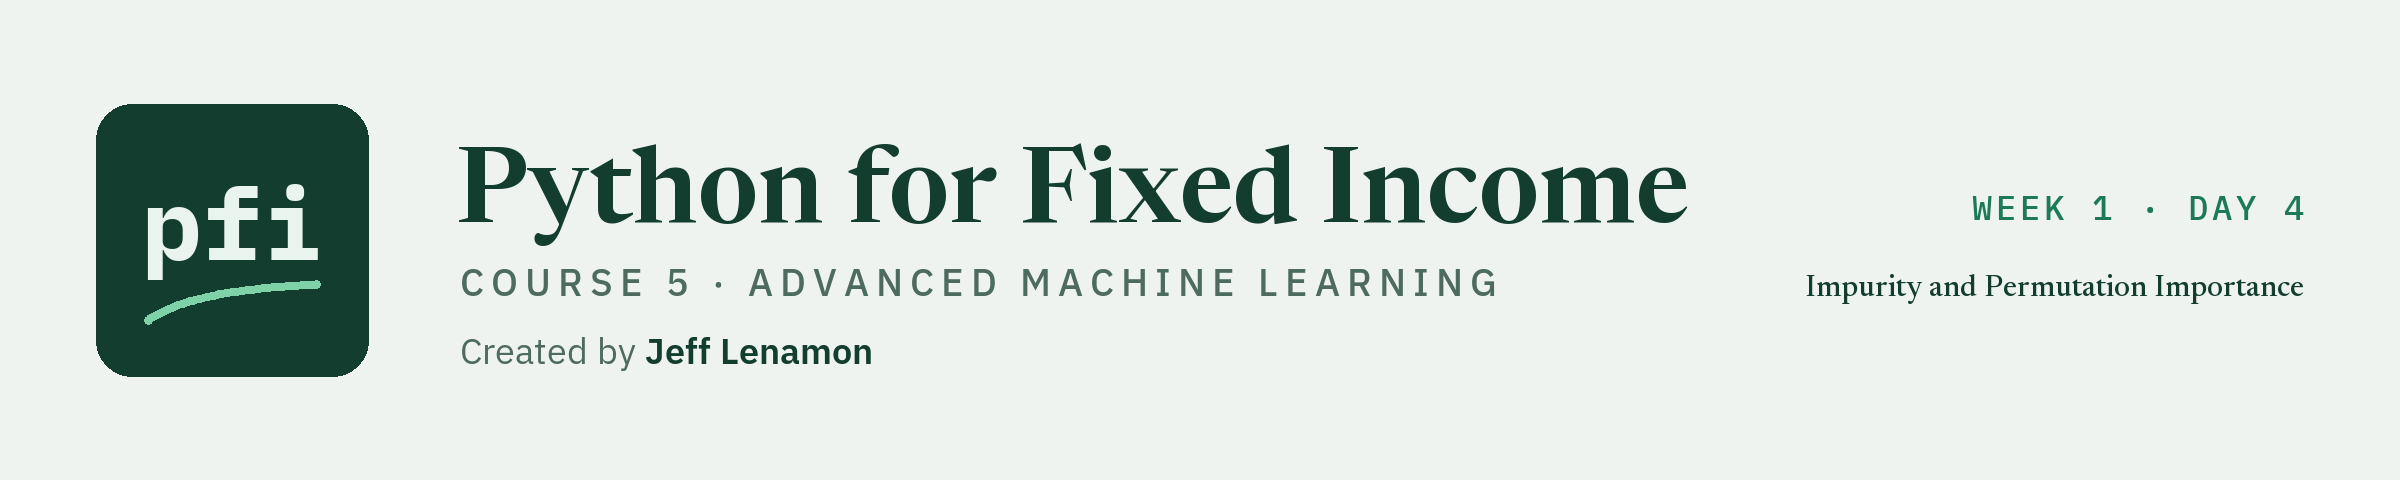

# Impurity and Permutation Importance

Week 1, Day 4. Two ways to rank a forest's columns, and why they disagree. Today: impurity importance against permutation importance, a column of random numbers that one of them ranks near the top, columns that share importance, and what importance on training rows measures.

**Data:** `credit_card_default.csv`, 30,000 card accounts in Taiwan in 2005: **real**, UCI Machine Learning Repository dataset 350, CC BY 4.0. Citation: Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course5_advanced_ml/week1/day4/04_impurity_and_permutation_importance.ipynb)

A forest fitted to the card file ranks the validation accounts well, and the next question on any desk is which columns it leans on. scikit-learn answers in one attribute, `feature_importances_`, and the answer looks authoritative: twenty numbers that add up to one. Course 4 day 9 showed a second answer, permutation importance on validation rows, for one pruned tree. Today puts the two side by side on a forest and tests them the simplest way there is: **add a column of random numbers and see which measure notices that it is worthless.**

**The card rules, as on every card day in this course.**

* **The data is real.** `credit_card_default.csv` is the UCI file Course 4 modelled in week 2: 30,000 credit card accounts with payment records from April to September 2005 and an outcome for the following month. The accounts are in Taiwan in 2005, and consumer credit there differs from US credit. Nothing here describes any other market.
* **People's attributes are never features.** `SEX`, `EDUCATION`, `MARRIAGE`, and `AGE` are never in a model and no output is grouped by them. Every model today uses Course 4's other 19 columns plus one column of random numbers, so the four person columns cannot appear in any importance table below: they were never in the model.
* **Course 4's split, rebuilt.** 18,000 training rows fit, 6,000 validation rows report, and Course 4's 6,000 test rows stay closed, by the test-row rule day 1 stated for the whole course.
* **A model's output is described, never acted on.** A forest's output is the model probability of default in this file, or a flag at a threshold. No output of either kind is a credit decision for any person. An importance describes the fitted model on these rows; it is not a cause of default and not a rule for lending.

Today you will:

1. Add `importance_table` to `ensemblekit.py`: both measures and their ranks in one table.
2. Add a column of random numbers to the card rows and watch impurity importance rank it near the top.
3. Shuffle one column by hand, then every column with `importance_table`, on the validation rows.
4. See why impurity importance rewards a column with many distinct values, and what leaf size does to that.
5. Watch six correlated columns share their importance.
6. Measure permutation importance on training rows, and say what it measures there.
7. Name an importance without calling it something it is not.

Q. Set up today's work folder: the thread settings, the seed, the card file, and the modules as day 3 left them.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, scikit-learn, XGBoost, or LightGBM is imported: if you ran another
# cell first, restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("xgboost", "xgboost"), ("lightgbm", "lightgbm"), ("imblearn", "imbalanced-learn"), ("shap", "shap"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course5_advanced_ml/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "scipy": "1.18.1", "xgboost": "3.4.1", "lightgbm": "4.7.0", "imbalanced-learn": "0.14.2", "shap": "0.52.0", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "credit_card_default.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course5_04_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["credit_card_default.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, scipy 1.18.1, xgboost 3.4.1, lightgbm 4.7.0, imbalanced-learn 0.14.2, shap 0.52.0, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course5_04_thtbjamp, in your temp folder
Data files from the data folder of the course repo: credit_card_default.csv
SEED = 42


Q. Write `mlkit.py`, Course 4's complete module, unchanged. `ensemblekit` imports it.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


Q. Write `ensemblekit.py` and `test_ensemblekit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile ensemblekit.py
"""ensemblekit: the pieces of ensembles, tuning, and rare-event modelling that the libraries leave to the analyst,
written down and tested.

Written day by day in Python for Fixed Income, Course 5: Advanced Machine Learning. It imports mlkit (Course 4's
module) and never changes it.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 5 never scores a row that Course 4 used as a test row. The course4_*_rows functions rebuild Course 4's
  splits exactly and return only the rows Course 5 may use; the closed rows are never returned.
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart.
- Every library call that can use more than one thread is given n_jobs=1, so every run gives the same digits.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from sklearn.model_selection import train_test_split  # Course 4's split, rebuilt

import mlkit  # Course 4's module: thresholds, metrics, splitters, and the no-leak check

# the card file: its outcome column and the 19 model columns (the four person columns are never features)
CARD_TARGET = "default payment next month"
CARD_FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]


def course4_card_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's 60/20/20 split of the card file, rebuilt, without its test rows.

    Input: frame, the 30,000 accounts of credit_card_default.csv as read by pd.read_csv.
    Output: X_train (18,000 rows), X_valid (6,000 rows), y_train, y_valid, with the 19 model columns in
    CARD_FEATURES and the file's row labels. Course 4's 6,000 test rows are never returned.
    Convention: the same two calls as Course 4: train_test_split(test_size=0.2, stratify=y, random_state=42), then
    the remaining 80 percent split with test_size=0.25, stratified, same seed. The validation rows were used in
    Course 4 to choose a threshold and a pruning level, never to fit.
    Raises ValueError if a column is missing or the frame does not have 30,000 rows.
    """
    # check the frame is the whole card file
    missing = [name for name in CARD_FEATURES + [CARD_TARGET] if name not in frame.columns]
    if missing:
        raise ValueError(f"frame lacks the columns {missing}")
    if len(frame) != 30_000:
        raise ValueError(f"frame must hold the 30,000 card accounts, not {len(frame)}")
    X, y = frame[CARD_FEATURES], frame[CARD_TARGET]
    # Course 4's first cut puts 20 percent aside as test rows: they are dropped here, never returned
    X_rest, _, y_rest, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    # Course 4's second cut: a quarter of the rest (20 percent of the file) as validation rows
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=42)
    mlkit.assert_disjoint(X_train.index, X_valid.index)
    return X_train, X_valid, y_train, y_valid


def bootstrap_positions(n_rows: int, seed: int = 42) -> np.ndarray:
    """Draw n_rows row positions with replacement: one bootstrap sample.

    Input: n_rows, how many rows the data has (at least 1); seed, the random seed.
    Output: an array of n_rows positions from 0 to n_rows - 1, in the order drawn. A position can appear more than
    once, and some positions do not appear at all (about 36.8 percent of them for large n_rows).
    Convention: np.random.default_rng(seed).integers(0, n_rows, n_rows), so the same seed gives the same sample.
    Excel: =RANDBETWEEN(1,n) draws one position but takes no seed and changes at every recalculation.
    Raises ValueError if n_rows is below 1.
    """
    if n_rows < 1:
        raise ValueError(f"n_rows must be at least 1, not {n_rows}")
    # one generator per call, seeded, so the draw does not depend on anything drawn before
    rng = np.random.default_rng(seed)
    return rng.integers(0, n_rows, n_rows)


def out_of_bag(n_rows: int, drawn: np.ndarray) -> np.ndarray:
    """The positions a bootstrap sample never drew: its out-of-bag rows.

    Inputs: n_rows, how many rows the data has; drawn, the positions of a bootstrap sample.
    Output: the sorted positions from 0 to n_rows - 1 that are not in drawn.
    Convention: a model fitted on the drawn rows has never seen these rows, so they can score it.
    Raises ValueError if drawn is empty or holds a position outside 0 to n_rows - 1.
    """
    positions = np.asarray(drawn)
    if positions.size == 0:
        raise ValueError("drawn is empty")
    if positions.min() < 0 or positions.max() > n_rows - 1:
        raise ValueError(f"drawn holds a position outside 0 to {n_rows - 1}")
    # every position, minus the ones drawn at least once
    return np.setdiff1d(np.arange(n_rows), positions)


from sklearn.metrics import roc_auc_score  # ranking quality from probabilities


def bagged_proba(bagging, X: pd.DataFrame) -> np.ndarray:
    """Bagging by hand: the average of each fitted tree's class-1 probability, each on its own columns.

    Inputs: bagging, a fitted BaggingClassifier; X, the rows to score, with the columns it was fitted on.
    Output: one number per row, the mean over bagging.estimators_ of each tree's class-1 probability on the
    columns listed in bagging.estimators_features_. It equals bagging.predict_proba(X)[:, 1] within 1e-12.
    Convention: a tree whose bootstrap sample held only one class gives 0 for class 1 when that class is 0.
    Excel: with each tree's column of outputs pasted side by side, =AVERAGE(B2:K2) filled down.
    Raises ValueError if bagging is not fitted.
    """
    if not hasattr(bagging, "estimators_"):
        raise ValueError("bagging is not fitted: call fit first")
    # the trees were fitted on plain arrays of the chosen columns, so score them the same way
    values = np.asarray(X, dtype=float)
    total = np.zeros(len(values))
    for tree, columns in zip(bagging.estimators_, bagging.estimators_features_):
        proba = tree.predict_proba(values[:, columns])
        # the tree's classes are positions in bagging.classes_; class 1 is position 1
        position = np.flatnonzero(tree.classes_ == 1)
        total += proba[:, position[0]] if position.size else 0.0
    return total / len(bagging.estimators_)


def oob_auc(model, y_train) -> float:
    """ROC AUC of the out-of-bag probabilities of a bagged model or a random forest.

    Inputs: model, fitted with oob_score=True on the training rows; y_train, those rows' outcomes, in order.
    Output: roc_auc_score(y_train, model.oob_decision_function_[:, 1]): each row scored only by the trees that
    did not draw it.
    Convention: model.oob_score_ is the accuracy of the out-of-bag votes for a classifier, not ROC AUC; this
    function gives the ranking number the course compares models by.
    Raises ValueError if the model was fitted without oob_score=True, or if a row has no out-of-bag vote (too few
    trees, so some row was drawn by every tree).
    """
    if not hasattr(model, "oob_decision_function_"):
        raise ValueError("the model has no out-of-bag outputs: fit it with oob_score=True")
    proba = model.oob_decision_function_[:, 1]
    if np.isnan(proba).any():
        raise ValueError(f"{int(np.isnan(proba).sum())} rows have no out-of-bag vote: use more trees")
    return float(roc_auc_score(y_train, proba))


def tree_correlation(forest, X: pd.DataFrame) -> float:
    """How much the trees of an ensemble agree: the mean pairwise correlation of their class-1 outputs.

    Inputs: forest, a fitted random forest, extra-trees, or bagging model (anything with estimators_, and
    estimators_features_ for bagging); X, the rows to score (validation rows).
    Output: the mean of the upper triangle of np.corrcoef over the trees' class-1 probabilities on X: 1 means
    every tree gives the same ranking, 0 means no linear agreement.
    Convention: averaging trees removes less noise the more they agree; a random forest tries a random subset of
    columns at each split to lower this number.
    Excel: =CORREL(B2:B6001,C2:C6001) for one pair of pasted tree columns.
    Raises ValueError if the ensemble has fewer than two trees.
    """
    trees = list(forest.estimators_)
    if len(trees) < 2:
        raise ValueError(f"need at least two trees, the ensemble has {len(trees)}")
    # each tree was fitted on a plain array; bagging may give each tree its own columns
    values = np.asarray(X, dtype=float)
    columns = getattr(forest, "estimators_features_", [slice(None)] * len(trees))
    outputs = np.array([tree.predict_proba(values[:, cols])[:, -1] for tree, cols in zip(trees, columns)])
    # the correlation of every pair of trees, then the mean above the diagonal
    matrix = np.corrcoef(outputs)
    return float(matrix[np.triu_indices(len(trees), k=1)].mean())

Writing ensemblekit.py


In [4]:
%%writefile test_ensemblekit.py
"""Tests for ensemblekit.py.

Expected values come from scikit-learn, XGBoost, LightGBM, imbalanced-learn, or SHAP on the same inputs, from
Course 4's published numbers, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from functools import cache
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import ensemblekit

HERE = Path(__file__).resolve().parent
SEED = 42


@cache
def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, read once per test run."""
    return pd.read_csv(HERE / "credit_card_default.csv")


@cache
def card_rows() -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's training and validation rows of the card file."""
    return ensemblekit.course4_card_rows(read_card())


def card_small(n: int = 3_000) -> tuple[pd.DataFrame, pd.Series]:
    """The first n of Course 4's training rows, for tests that fit many models and must stay fast."""
    X_train, _, y_train, _ = card_rows()
    return X_train.iloc[:n], y_train.iloc[:n]


def course4_card_test_labels() -> set:
    """The row labels of Course 4's card test set, recomputed with Course 4's own call."""
    card = read_card()
    y = card[ensemblekit.CARD_TARGET]
    _, X_test = train_test_split(card, test_size=0.2, stratify=y, random_state=SEED)
    return set(X_test.index)


def test_course4_card_rows_counts():
    X_train, X_valid, y_train, y_valid = card_rows()
    assert (len(X_train), len(X_valid), len(y_train), len(y_valid)) == (18_000, 6_000, 18_000, 6_000)
    assert list(X_train.columns) == ensemblekit.CARD_FEATURES
    for person in ("SEX", "EDUCATION", "MARRIAGE", "AGE", "ID"):
        assert person not in X_train.columns
    with pytest.raises(ValueError):
        ensemblekit.course4_card_rows(read_card().iloc[:100])


def test_course4_card_rows_closed_rows():
    X_train, X_valid, _, _ = card_rows()
    closed = course4_card_test_labels()
    assert len(closed) == 6_000
    assert not closed & set(X_train.index)
    assert not closed & set(X_valid.index)


def test_course4_card_rows_reproduces_logistic():
    X_train, X_valid, y_train, y_valid = card_rows()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    # Course 4 day 10's validation ROC AUC for the scaled logistic regression
    assert round(roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1]), 4) == 0.7190


def test_bootstrap_positions_with_replacement():
    drawn = ensemblekit.bootstrap_positions(1_000)
    assert drawn.shape == (1_000,)
    assert drawn.min() >= 0 and drawn.max() <= 999
    # with replacement: some rows twice, so fewer distinct positions than rows
    assert len(np.unique(drawn)) < 1_000
    with pytest.raises(ValueError):
        ensemblekit.bootstrap_positions(0)


def test_bootstrap_positions_seeded():
    first = ensemblekit.bootstrap_positions(500, seed=SEED)
    assert np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=SEED))
    assert np.array_equal(first, np.random.default_rng(SEED).integers(0, 500, 500))
    assert not np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=7))


def test_out_of_bag_hand():
    # rows 0 to 5; the sample drew 0, 0, 2, 5, 5, 5: rows 1, 3, 4 were never drawn
    left_out = ensemblekit.out_of_bag(6, np.array([0, 0, 2, 5, 5, 5]))
    assert left_out.tolist() == [1, 3, 4]
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([0, 6]))
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([], dtype=int))


def test_out_of_bag_share_near_e():
    n = 18_000
    drawn = ensemblekit.bootstrap_positions(n)
    left_out = ensemblekit.out_of_bag(n, drawn)
    # no row is both drawn and out of bag
    assert not set(left_out.tolist()) & set(drawn.tolist())
    # (1 - 1/n)^n tends to 1/e = 0.3679
    assert abs(len(left_out) / n - np.exp(-1)) < 0.01


from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier


def small_bagging(n_estimators: int = 10, oob: bool = False) -> tuple[BaggingClassifier, pd.DataFrame, pd.Series]:
    X, y = card_small()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=n_estimators,
                                oob_score=oob, random_state=SEED, n_jobs=1)
    return bagging.fit(X, y), X, y


def test_bagged_proba_matches_sklearn():
    bagging, X, _ = small_bagging()
    _, X_valid, _, _ = card_rows()
    assert ensemblekit.bagged_proba(bagging, X_valid) == pytest.approx(bagging.predict_proba(X_valid)[:, 1], abs=1e-12)
    # also with a random half of the columns per tree, so estimators_features_ matters
    X, y = card_small()
    half = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, max_features=0.5,
                             random_state=SEED, n_jobs=1).fit(X, y)
    assert ensemblekit.bagged_proba(half, X_valid) == pytest.approx(half.predict_proba(X_valid)[:, 1], abs=1e-12)


def test_bagged_proba_rejects_unfitted():
    with pytest.raises(ValueError, match="not fitted"):
        ensemblekit.bagged_proba(BaggingClassifier(random_state=SEED), card_small()[0])


def test_oob_auc_matches_roc_auc():
    bagging, _, y = small_bagging(n_estimators=40, oob=True)
    assert ensemblekit.oob_auc(bagging, y) == pytest.approx(roc_auc_score(y, bagging.oob_decision_function_[:, 1]),
                                                            abs=1e-12)
    # oob_score_ is accuracy, a different number
    assert ensemblekit.oob_auc(bagging, y) != pytest.approx(bagging.oob_score_, abs=1e-3)


def test_oob_auc_requires_oob_score():
    bagging, _, y = small_bagging()
    with pytest.raises(ValueError, match="oob_score=True"):
        ensemblekit.oob_auc(bagging, y)


from types import SimpleNamespace

from sklearn.ensemble import RandomForestClassifier


class StandInTree:
    """A stand-in for a fitted tree: its class-1 output is the first column plus a constant."""

    def __init__(self, shift: float):
        self.shift = shift

    def predict_proba(self, values: np.ndarray) -> np.ndarray:
        p = values[:, 0] / 10 + self.shift
        return np.column_stack([1 - p, p])


def test_tree_correlation_hand():
    X = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0], "b": [0.0, 0.0, 1.0, 1.0]})
    # two outputs that differ by a constant are perfectly correlated
    forest = SimpleNamespace(estimators_=[StandInTree(0.1), StandInTree(0.3)])
    assert ensemblekit.tree_correlation(forest, X) == pytest.approx(1.0, abs=1e-12)


def test_tree_correlation_forest_below_bagging():
    X, y = card_small()
    _, X_valid, _, _ = card_rows()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, random_state=SEED,
                                n_jobs=1).fit(X, y)
    forest = RandomForestClassifier(n_estimators=10, random_state=SEED, n_jobs=1).fit(X, y)
    assert forest.estimators_[0].max_features == "sqrt"
    assert ensemblekit.tree_correlation(forest, X_valid) < ensemblekit.tree_correlation(bagging, X_valid)


def test_tree_correlation_rejects_one_tree():
    X, y = card_small(500)
    forest = RandomForestClassifier(n_estimators=1, random_state=SEED, n_jobs=1).fit(X, y)
    with pytest.raises(ValueError, match="at least two trees"):
        ensemblekit.tree_correlation(forest, X)

Writing test_ensemblekit.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import ensemblekit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(ensemblekit)

# the functions and classes defined in ensemblekit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(ensemblekit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "ensemblekit" and not name.startswith("_")]
print(f"ensemblekit functions: {functions}")

ensemblekit functions: ['course4_card_rows', 'bootstrap_positions', 'out_of_bag', 'bagged_proba', 'oob_auc', 'tree_correlation']


## 4.1 Two Importances

A forest gives two different answers to "which columns does it lean on".

* **Impurity importance** comes free with the fit. Every split in every tree lowers the Gini impurity of the training rows it splits. Credit that decrease to the split's column, weighted by the share of rows reaching the node, add it up over the tree, average over the trees, and scale the result to sum to 1. That is `feature_importances_`. It is computed from the **training rows**, during the fit.
* **Permutation importance** is measured afterwards, on rows the model did not see. Shuffle one column, so its values no longer line up with their accounts, score the model again, and record how far the score falls. Repeat the shuffle a few times and average. A column the model leans on costs a lot when it is broken; a column it ignores costs nothing.

Q. Add `importance_table` to `ensemblekit.py`: both measures and their ranks in one table. Read the docstring first.

In [6]:
%%writefile -a ensemblekit.py


from sklearn.inspection import permutation_importance  # the drop in a score when one column is shuffled


def importance_table(model, X_valid: pd.DataFrame, y_valid, scoring: str = "roc_auc", n_repeats: int = 5,
                     seed: int = 42) -> pd.DataFrame:
    """Two importance measures side by side: impurity importance and permutation importance.

    Inputs: model, a fitted tree ensemble with feature_importances_, fitted on a DataFrame; X_valid, y_valid,
    rows the model was NOT fitted on (validation rows); scoring, the score whose drop is measured; n_repeats, how
    many shuffles per column; seed, the random seed of the shuffles.
    Output: a DataFrame indexed by feature with columns impurity (model.feature_importances_, from the training
    rows, sums to 1), permutation (the mean drop in the score over n_repeats shuffles of that column),
    permutation_sd (their standard deviation), impurity_rank and permutation_rank (1 = largest), sorted by
    permutation, largest first.
    Convention: impurity importance is learned on the training rows and rewards columns the trees could split on
    to fit noise; permutation importance on unseen rows measures how much the score leans on a column there.
    Neither measure is a cause. permutation_importance runs with n_jobs=1.
    Raises ValueError if the model has no feature_importances_ (an unfitted model, or a linear model).
    """
    if not hasattr(model, "feature_importances_"):
        raise ValueError("the model has no feature_importances_: fit a tree ensemble first")
    # shuffle each column n_repeats times on the rows given and record the drop in the score
    result = permutation_importance(model, X_valid, y_valid, scoring=scoring, n_repeats=n_repeats,
                                    random_state=seed, n_jobs=1)
    table = pd.DataFrame({"impurity": model.feature_importances_, "permutation": result.importances_mean,
                          "permutation_sd": result.importances_std}, index=pd.Index(X_valid.columns, name="feature"))
    # rank 1 is the largest value; ties share the better rank
    table["impurity_rank"] = table["impurity"].rank(ascending=False, method="min").astype(int)
    table["permutation_rank"] = table["permutation"].rank(ascending=False, method="min").astype(int)
    return table.sort_values("permutation", ascending=False, kind="stable")

Appending to ensemblekit.py


* The impurity column is the model's own `feature_importances_`. The permutation columns come from scikit-learn's `permutation_importance`, run on the rows you pass, with `n_jobs=1` and the seed, so every run shuffles the same way.
* Rank 1 is the largest value in each column. The table is sorted by permutation importance, largest first.
* The docstring says the rows must be rows the model was **not** fitted on. Section 4.6 breaks that rule on purpose, to show what it changes.
* A model without `feature_importances_`, a logistic regression for example, is refused with a `ValueError`.

Q. Add today's four tests.

In [7]:
%%writefile -a test_ensemblekit.py


from sklearn.inspection import permutation_importance


@cache
def forest_with_noise() -> tuple[RandomForestClassifier, pd.DataFrame, pd.Series]:
    """A 50-tree forest with 20-row leaves on 3,000 training rows plus a column of random numbers, and 2,000
    validation rows with their own random column."""
    X, y = card_small()
    _, X_valid, _, y_valid = card_rows()
    rng = np.random.default_rng(SEED)
    X = X.assign(noise=rng.normal(size=len(X)))
    X_valid = X_valid.iloc[:2_000].assign(noise=rng.normal(size=2_000))
    forest = RandomForestClassifier(n_estimators=50, min_samples_leaf=20, random_state=SEED, n_jobs=1).fit(X, y)
    return forest, X_valid, y_valid.iloc[:2_000]


def test_importance_table_columns_and_ranks():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid)
    assert list(table.columns) == ["impurity", "permutation", "permutation_sd", "impurity_rank", "permutation_rank"]
    assert set(table.index) == set(X_valid.columns)
    assert table["impurity"].sum() == pytest.approx(1.0, abs=1e-12)
    assert table["permutation"].is_monotonic_decreasing
    assert table["permutation_rank"].iloc[0] == 1
    assert table.loc[table["impurity"].idxmax(), "impurity_rank"] == 1


def test_importance_table_matches_permutation_importance():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid, n_repeats=3)
    direct = permutation_importance(forest, X_valid, y_valid, scoring="roc_auc", n_repeats=3, random_state=SEED,
                                    n_jobs=1)
    expected = pd.Series(direct.importances_mean, index=X_valid.columns)
    assert table["permutation"].to_numpy() == pytest.approx(expected[table.index].to_numpy(), abs=1e-12)


def test_importance_table_noise_near_zero():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid)
    # on unseen rows, shuffling a column of random numbers costs (almost) nothing
    assert abs(table.loc["noise", "permutation"]) < 0.01
    assert table.loc["PAY_0", "permutation"] > 10 * abs(table.loc["noise", "permutation"])


def test_importance_table_rejects_model_without_importances():
    X, y = card_small(500)
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]).fit(X, y)
    with pytest.raises(ValueError, match="feature_importances_"):
        ensemblekit.importance_table(model, X, y)

Appending to test_ensemblekit.py


* The tests share one small model, cached so it is fitted once: a 50-tree forest with 20-row leaves on the first 3,000 training rows, with its own column of random numbers, scored on 2,000 validation rows. They check the table's columns and ranks, that the permutation column equals `permutation_importance` called directly (within 1e-12), that the random column's permutation importance is near zero while `PAY_0`'s is more than ten times larger, and that a logistic regression is refused.

Q. Reload the module and run every test.

In [8]:
# the file changed, so reload before using the new function
importlib.reload(ensemblekit)
print(f"importance_table in ensemblekit: {hasattr(ensemblekit, 'importance_table')}")

importance_table in ensemblekit: True


In [9]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
# the run time changes from run to run, so a duration over a minute is left out of the summary line
import re
print(re.sub(r" \(\d+:\d\d:\d\d\)", "", result.stdout + result.stderr))

..................                                                       [100%]
18 passed in 10.62s



* `18 passed`: the 14 tests of days 1 to 3, and today's 4.

## 4.2 A Column of Random Numbers

The test is simple. Add a column of numbers drawn at random, unrelated to anything in the file, to the training rows and to the validation rows. A good importance measure should give it nothing.

Q. Load the card rows and add a column named `noise` to both.

In [10]:
# the 30,000 UCI card accounts (real data, CC BY 4.0; the citation is under the title)
card = pd.read_csv("credit_card_default.csv")
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)
# the four columns that describe people are never features: stop if one slips in
assert not set(X_train.columns) & {"SEX", "EDUCATION", "MARRIAGE", "AGE"}, "a person column is in the features"

# a column of random numbers from a normal distribution, seeded: training rows first, then validation rows
rng = np.random.default_rng(SEED)
X_train = X_train.assign(noise=rng.normal(size=len(X_train)))
X_valid = X_valid.assign(noise=rng.normal(size=len(X_valid)))

print(f"training rows: {len(X_train):,}, validation rows: {len(X_valid):,}, columns: {X_train.shape[1]}")
print(f"noise on the training rows: mean {X_train['noise'].mean():.4f}, standard deviation {X_train['noise'].std():.4f}")
print(f"correlation of noise with the outcome on the training rows: {np.corrcoef(X_train['noise'], y_train)[0, 1]:.4f}")

training rows: 18,000, validation rows: 6,000, columns: 20
noise on the training rows: mean -0.0016, standard deviation 1.0035
correlation of noise with the outcome on the training rows: -0.0086


* 20 columns now: Course 4's 19 and `noise`. Its correlation with the outcome is -0.0086, which is what a column of random numbers gives on 18,000 rows: the outcome had no part in drawing it. Any importance it receives is importance a measure gives to nothing.

Q. Fit a 200-tree forest with full trees (scikit-learn's default leaves, as day 3 began) on the 20 columns, and score it on the validation rows.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

# 200 full trees: every tree splits until its leaves are pure; n_jobs=1 and the seed, as every Course 5 forest
forest = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=1).fit(X_train, y_train)

# the forest's model probability of default in this file, on every validation account
proba_valid = forest.predict_proba(X_valid)[:, 1]
print(f"forest, full trees: validation ROC AUC {roc_auc_score(y_valid, proba_valid):.4f}, "
      f"average precision {average_precision_score(y_valid, proba_valid):.4f}")

forest, full trees: validation ROC AUC 0.7667, average precision 0.5224


**Rows.** Every model on the card file in this notebook is fitted on Course 4's 18,000 training rows and scored on Course 4's 6,000 validation rows (section 4.6 also shuffles columns on training rows, to show what that measures); Course 4's 6,000 test rows are never scored in this course.

* The output is the model probability of default in this file. The forest ranks the validation accounts at 0.7667, a sound forest for this file; the question today is only what the two measures say about its columns.

Q. Which columns does impurity importance rank highest?

In [12]:
# impurity importance: the model's own feature_importances_, learned from the training rows, summing to 1
impurity = pd.Series(forest.feature_importances_, index=X_train.columns, name="impurity importance")
impurity = impurity.sort_values(ascending=False)
ranked = impurity.to_frame().assign(rank=range(1, len(impurity) + 1))
print(ranked.round(4).to_string())
print(f"sum of the impurity importances: {impurity.sum():.4f}")

           impurity importance  rank
PAY_0                   0.0995     1
noise                   0.0943     2
BILL_AMT1               0.0620     3
LIMIT_BAL               0.0606     4
BILL_AMT2               0.0556     5
BILL_AMT3               0.0532     6
PAY_AMT1                0.0519     7
BILL_AMT6               0.0518     8
BILL_AMT4               0.0517     9
BILL_AMT5               0.0509    10
PAY_AMT2                0.0490    11
PAY_AMT6                0.0472    12
PAY_2                   0.0471    13
PAY_AMT3                0.0468    14
PAY_AMT5                0.0448    15
PAY_AMT4                0.0434    16
PAY_3                   0.0283    17
PAY_5                   0.0227    18
PAY_4                   0.0211    19
PAY_6                   0.0179    20
sum of the impurity importances: 1.0000


* **The column of random numbers ranks 2nd of 20** by impurity importance, at 0.0943, just below `PAY_0` (0.0995) and above `BILL_AMT1` and every other real column. 5 of the six repayment-status columns rank below it; only `PAY_0` is above.
* Read naively, this table says the forest leans on `noise` almost as much as on the latest repayment status. It does not, as the next section shows. Impurity importance measures how much each column was **used to split the training rows**, and full trees split on anything that separates a few training rows.

## 4.3 Permutation Importance on Validation Rows

Permutation importance asks a different question: **on rows the forest never saw, how much worse does it rank the accounts when one column is broken?** Before the function does it twenty times over, do it once by hand.

Q. Shuffle `PAY_0` on the validation rows, once, and score the forest again.

In [13]:
# a copy of the validation rows with PAY_0 shuffled: the same values, handed to the wrong accounts
shuffled = X_valid.copy()
shuffled["PAY_0"] = np.random.default_rng(SEED).permutation(shuffled["PAY_0"].to_numpy())

auc_valid = roc_auc_score(y_valid, proba_valid)
auc_shuffled = roc_auc_score(y_valid, forest.predict_proba(shuffled)[:, 1])
print(f"validation ROC AUC: {auc_valid:.4f} as fitted, {auc_shuffled:.4f} with PAY_0 shuffled")
print(f"the drop from one shuffle of PAY_0: {auc_valid - auc_shuffled:.4f}")

validation ROC AUC: 0.7667 as fitted, 0.7051 with PAY_0 shuffled
the drop from one shuffle of PAY_0: 0.0616


* Shuffling `PAY_0` costs the forest 0.0616 of validation ROC AUC: with the latest repayment status handed to the wrong accounts, the forest ranks the accounts much worse. The forest was not refitted: the same trees met a broken column.
* That drop is one shuffle. Another shuffle gives a slightly different number, so `importance_table` shuffles each column five times and reports the mean and the standard deviation.

Q. Do it for every column with `importance_table`, on the validation rows.

In [14]:
# both importances of the forest; the permutation columns shuffle each column 5 times on the validation rows
table = ensemblekit.importance_table(forest, X_valid, y_valid)
print(table.round(4).to_string())

           impurity  permutation  permutation_sd  impurity_rank  permutation_rank
feature                                                                          
PAY_0        0.0995       0.0702          0.0034              1                 1
LIMIT_BAL    0.0606       0.0278          0.0049              4                 2
PAY_AMT1     0.0519       0.0183          0.0021              7                 3
PAY_2        0.0471       0.0122          0.0014             13                 4
PAY_AMT2     0.0490       0.0084          0.0019             11                 5
PAY_3        0.0283       0.0046          0.0011             17                 6
PAY_4        0.0211       0.0046          0.0013             19                 7
BILL_AMT1    0.0620       0.0033          0.0036              3                 8
PAY_6        0.0179       0.0029          0.0009             20                 9
PAY_AMT3     0.0468       0.0025          0.0014             14                10
BILL_AMT3    0.0

* Impurity importance and permutation importance (the drop in validation ROC AUC when that column is shuffled) side by side. The forest leans on `PAY_0` most (0.0702), then `LIMIT_BAL` (0.0278). `PAY_0`'s mean drop over five shuffles differs from section 4.3's one shuffle by hand (0.0616), because these are other shuffles: the function's own seeded ones.
* **The noise column's permutation importance is -0.0015**, with a standard deviation of 0.0011 over the five shuffles: zero, within the noise of shuffling. It ranks 18th of 20 here and 2nd by impurity importance.
* 5 columns have a small negative permutation importance (`BILL_AMT2`, `PAY_AMT6`, `noise`, `BILL_AMT5`, `BILL_AMT6`): shuffling them happened to raise the score slightly. A negative number is not a column that hurts the model; it is a column whose drop is too small to tell from zero on 6,000 rows.

Q. Draw the two importances side by side, with the noise column in red.

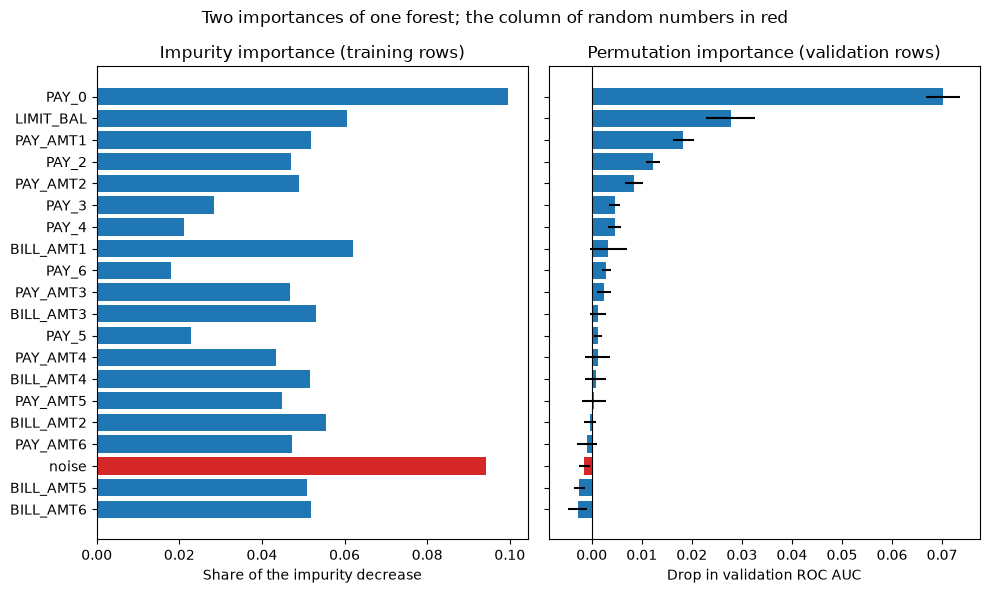

In [15]:
import matplotlib.pyplot as plt

# the columns in the table's order, largest permutation importance at the top
order = table.index[::-1]
colours = ["tab:red" if name == "noise" else "tab:blue" for name in order]
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
axes[0].barh(order, table.loc[order, "impurity"], color=colours)
axes[0].set_title("Impurity importance (training rows)")
axes[0].set_xlabel("Share of the impurity decrease")
axes[1].barh(order, table.loc[order, "permutation"], xerr=table.loc[order, "permutation_sd"], color=colours)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Permutation importance (validation rows)")
axes[1].set_xlabel("Drop in validation ROC AUC")
fig.suptitle("Two importances of one forest; the column of random numbers in red")
plt.tight_layout()
plt.show()

* On the left, the red bar is the second longest. On the right, it sits on the zero line with the columns the forest does not lean on. Two measures of the same forest, and they disagree most about the one column whose true worth is known.

## 4.4 Why Impurity Importance Rewards the Noise Column

A split is chosen on the training rows of a node: of the columns the tree may try, the one whose best threshold lowers the impurity most wins. Near the top of a tree, nodes hold thousands of rows and only a real association with the outcome lowers the impurity much. A full tree keeps splitting until its leaves are pure, so deep down it reaches nodes of a handful of rows, and there a column with thousands of distinct values offers thousands of thresholds. One of them will separate a few defaults from a few non-defaults **by chance**, and that split is credited to the column. Summed over hundreds of deep nodes and 200 trees, chance adds up.

Q. How many distinct values does each column have?

In [16]:
# distinct values per column on the training rows, beside the impurity rank
distinct = pd.DataFrame({"distinct values": X_train.nunique(), "impurity rank": table["impurity_rank"]})
print(distinct.sort_values("distinct values", ascending=False).to_string())

           distinct values  impurity rank
noise                18000              2
BILL_AMT1            14404              3
BILL_AMT2            14207              5
BILL_AMT3            13976              6
BILL_AMT4            13747              9
BILL_AMT5            13382             10
BILL_AMT6            13167              8
PAY_AMT1              5717              7
PAY_AMT2              5688             11
PAY_AMT3              5417             14
PAY_AMT4              5030             16
PAY_AMT6              4988             12
PAY_AMT5              4958             15
LIMIT_BAL               78              4
PAY_0                   11              1
PAY_2                   11             13
PAY_3                   11             17
PAY_4                   11             19
PAY_5                   10             18
PAY_6                   10             20


* `noise` has 18,000 distinct values, one per row. The bill amounts have 13,167 to 14,404, the payment amounts 4,958 to 5,717, and the repayment-status columns 10 or 11.
* The columns with many values take most of the impurity ranks near the top, whatever their worth on the validation rows. `PAY_0` shows the measure can still see a strong association: with 11 values it ranks first, because its splits near the top of the trees lower the impurity of thousands of rows at once.

If the bias comes from splitting nodes of a handful of rows, stopping the trees before they get there should shrink it.

Q. Fit the same forest with at least 20 training rows in every leaf, and compare the noise column's place.

In [17]:
# the same 200 trees, each stopping when a split would leave fewer than 20 training rows in a leaf
forest_20 = RandomForestClassifier(n_estimators=200, min_samples_leaf=20, random_state=SEED, n_jobs=1).fit(X_train, y_train)
proba_20 = forest_20.predict_proba(X_valid)[:, 1]
table_20 = ensemblekit.importance_table(forest_20, X_valid, y_valid)

noise_rows = pd.DataFrame({
    "validation ROC AUC": [roc_auc_score(y_valid, proba_valid), roc_auc_score(y_valid, proba_20)],
    "noise impurity": [table.loc["noise", "impurity"], table_20.loc["noise", "impurity"]],
    "noise impurity rank": [table.loc["noise", "impurity_rank"], table_20.loc["noise", "impurity_rank"]],
    "noise permutation": [table.loc["noise", "permutation"], table_20.loc["noise", "permutation"]],
    "noise permutation rank": [table.loc["noise", "permutation_rank"], table_20.loc["noise", "permutation_rank"]],
}, index=["full trees", "20-row leaves"])
print(noise_rows.round(4).to_string())
print(f"top three by impurity importance, 20-row leaves: {table_20.sort_values('impurity', ascending=False).index[:3].tolist()}")

               validation ROC AUC  noise impurity  noise impurity rank  noise permutation  noise permutation rank
full trees                 0.7667          0.0943                    2            -0.0015                      18
20-row leaves              0.7861          0.0333                   10             0.0005                      20
top three by impurity importance, 20-row leaves: ['PAY_0', 'PAY_2', 'PAY_3']


* With 20-row leaves the noise column's impurity importance falls from 0.0943 to 0.0333, and its rank from 2nd to 10th of 20. Its permutation importance stays near zero (0.0005). `PAY_0`'s impurity importance rises to 0.2672, and the top three are now `PAY_0`, `PAY_2`, `PAY_3`: with the chance splits gone, the real ones carry more of the total.
* It does not fall to last. A 20-row leaf still lets a tree split a node of 40 rows or more, and a column of 18,000 distinct values still finds chance splits there. Impurity importance is never zero for a column a tree can split on, so it cannot tell you a column is worthless.
* Leaf size changes the model as well as its importances: the forest with 20-row leaves ranks the validation accounts better (0.7861 against 0.7667).

## 4.5 Correlated Columns Share Importance

The card file holds six monthly bill amounts, `BILL_AMT1` (the bill statement of September 2005) to `BILL_AMT6` (April 2005). One month's bill and the next belong to the same account, so expect them to move together. Check.

Q. How closely do the six bill amounts move together on the training rows?

In [18]:
bills = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
# Pearson correlation of every pair of bill amounts on the training rows
print(X_train[bills].corr().round(2).to_string())

           BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6
BILL_AMT1       1.00       0.95       0.90       0.86       0.83       0.80
BILL_AMT2       0.95       1.00       0.94       0.89       0.86       0.83
BILL_AMT3       0.90       0.94       1.00       0.93       0.90       0.86
BILL_AMT4       0.86       0.89       0.93       1.00       0.94       0.90
BILL_AMT5       0.83       0.86       0.90       0.94       1.00       0.94
BILL_AMT6       0.80       0.83       0.86       0.90       0.94       1.00


* Every pair correlates between 0.80 and 0.95. Neighbouring months correlate most.

Now look back at the table of section 4.3. Each bill amount, shuffled on its own, costs the forest between -0.0028 and 0.0033 of validation ROC AUC: on permutation importance, all six look close to worthless. But when one is shuffled, the forest still has five others that carry nearly the same information, and its trees split on whichever is left.

Q. Shuffle all six bill amounts together, five times, with one shuffle of the rows for the six columns each time.

In [19]:
# shuffle the six columns as a block: each account gets another account's six bill amounts, together
rng = np.random.default_rng(SEED)
group_drops = []
for repeat in range(5):
    order = rng.permutation(len(X_valid))
    broken = X_valid.copy()
    broken[bills] = X_valid[bills].to_numpy()[order]
    group_drops.append(auc_valid - roc_auc_score(y_valid, forest.predict_proba(broken)[:, 1]))

print(f"the six bill amounts shuffled together: mean drop {np.mean(group_drops):.4f}, standard deviation {np.std(group_drops):.4f}")
print(f"the six shuffled one at a time, added up: {table.loc[bills, 'permutation'].sum():.4f}")
print(f"their impurity importance, added up: {table.loc[bills, 'impurity'].sum():.4f}")

the six bill amounts shuffled together: mean drop 0.0230, standard deviation 0.0028
the six shuffled one at a time, added up: -0.0002
their impurity importance, added up: 0.3252


* Shuffled together, the six bill amounts cost 0.0230 of validation ROC AUC (standard deviation 0.0028); one at a time, their drops add up to -0.0002. The forest does lean on the bills, as a group. **Permutation importance of one column measures what the model loses when that column alone is broken**, and with five close copies left, it loses almost nothing.
* Impurity importance splits the credit the other way: the trees split on all six, so together they hold 0.3252 of the total, each a sixth or so. Neither measure reports the group's worth column by column. When columns are correlated, shuffle them together, or drop all but one and refit (Exercise 2 does that).

## 4.6 Permutation Importance on Training Rows

`importance_table`'s docstring says to pass rows the model was not fitted on. What happens on training rows? To compare like with like, use 6,000 of them, as many as there are validation rows: the first 6,000 in the split's own shuffled order.

Q. Run `importance_table` on 6,000 training rows, against the docstring, and compare.

In [20]:
# 6,000 training rows, as many as the validation rows: rows every tree's sample could have drawn
X_some, y_some = X_train.iloc[:6000], y_train.iloc[:6000]
print(f"forest on these training rows: ROC AUC {roc_auc_score(y_some, forest.predict_proba(X_some)[:, 1]):.4f}")

table_train = ensemblekit.importance_table(forest, X_some, y_some)
compare = pd.DataFrame({"validation rows": table["permutation"], "training rows": table_train["permutation"],
                        "training sd": table_train["permutation_sd"], "training rank": table_train["permutation_rank"]})
print(compare.sort_values("training rows", ascending=False).round(4).to_string())

forest on these training rows: ROC AUC 1.0000


           validation rows  training rows  training sd  training rank
feature                                                              
PAY_0               0.0702         0.0554       0.0014              1
LIMIT_BAL           0.0278         0.0293       0.0011              2
BILL_AMT1           0.0033         0.0082       0.0002              3
noise              -0.0015         0.0079       0.0005              4
PAY_AMT6           -0.0010         0.0049       0.0003              5
PAY_AMT1            0.0183         0.0036       0.0003              6
PAY_AMT2            0.0084         0.0023       0.0001              7
PAY_2               0.0122         0.0022       0.0002              8
PAY_AMT3            0.0025         0.0019       0.0002              9
PAY_AMT5            0.0005         0.0009       0.0001             10
PAY_3               0.0046         0.0009       0.0000             11
PAY_AMT4            0.0012         0.0007       0.0000             12
BILL_AMT3           

* On rows it was fitted on, the forest ranks perfectly to 4 decimals (ROC AUC 1.0000): each row sits in about two thirds of the trees' bootstrap samples, and full trees fitted their samples to the leaf.
* **On the training rows the noise column's permutation importance is 0.0079, 4th of 20**, about 16 standard deviations above zero; on the validation rows it was -0.0015. The trees used `noise` to fit these very rows, so breaking it breaks that fit.
* So permutation importance on training rows measures **how much the model uses a column on the rows it learned, including to fit noise**. That is a fact about the fit, not about how the model behaves on accounts it has not seen. Only rows the model never saw answer that, which is why the function's docstring asks for them.

Q. Draw permutation importance on the two kinds of rows.

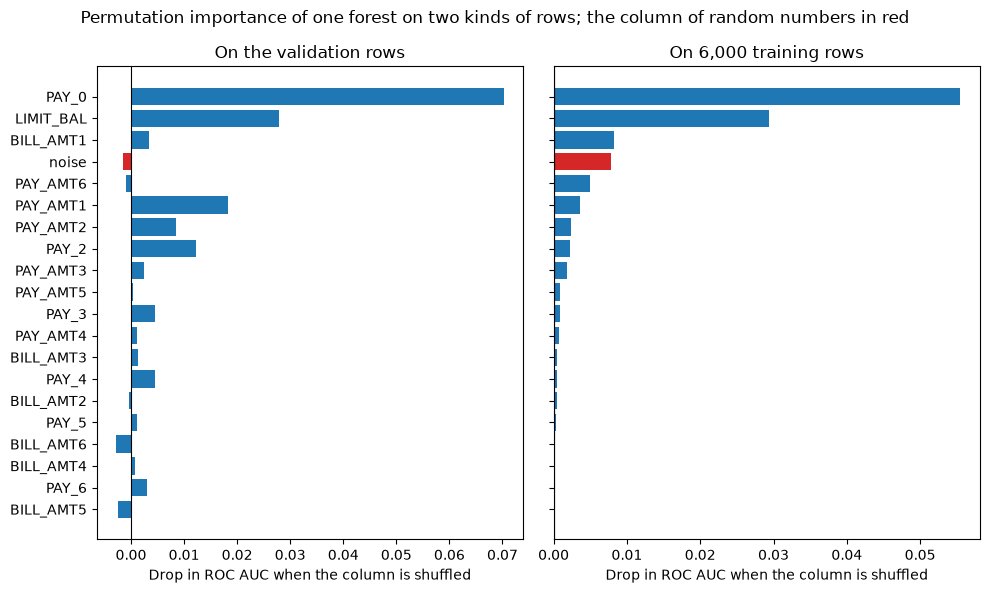

In [21]:
order = compare.sort_values("training rows").index
colours = ["tab:red" if name == "noise" else "tab:blue" for name in order]
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
axes[0].barh(order, compare.loc[order, "validation rows"], color=colours)
axes[0].set_title("On the validation rows")
axes[1].barh(order, compare.loc[order, "training rows"], color=colours)
axes[1].set_title("On 6,000 training rows")
for ax in axes:
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Drop in ROC AUC when the column is shuffled")
fig.suptitle("Permutation importance of one forest on two kinds of rows; the column of random numbers in red")
plt.tight_layout()
plt.show()

* On the right, the red bar stands out among the real columns; on the left, it is gone. Same forest, same function, different rows.

## 4.7 What to Call an Importance

An importance is a number about a fitted model on a set of rows. The course gives it these names, and only these:

* **impurity importance**: the share of the impurity decrease credited to a column in the training rows;
* **permutation importance**: the drop in validation ROC AUC (or average precision) when that column is shuffled;
* **the model leans on** a column, or a column's **association in this file** with the outcome.

The words people reach for are stronger, and they are wrong here. An importance is never a driver or a key driver of default. It is never a cause, and it does not name a determinant or a risk factor. `PAY_0` first on permutation importance says that this forest ranks these accounts much worse without it. It does not say that a late payment brings a default about, and it says nothing about what would happen to an account if its payment status changed. Two of today's findings make the point: impurity importance put a column of random numbers 2nd, and permutation importance put six closely related columns near zero one at a time. A measure that can do either is not a statement about the world.

## 4.8 Importance in Boosted Models

Week 2 fits boosted trees: AdaBoost, gradient boosting, XGBoost, and LightGBM. Boosting libraries report their own built-in importances, under names such as **gain** (the improvement in the fit credited to a column, close in spirit to impurity importance) and **split count** (how many times a column is used to split). Those are learned on the training rows too, and on the same model they can disagree with each other as well as with permutation importance. Permutation importance on validation rows works the same way on any fitted model, because it only shuffles a column and scores again. Day 14 adds a third view, SHAP values, which split one row's output across the columns.

## Excel Side by Side

Excel has no worksheet function for a random forest, for impurity importance, or for a shuffle with a seed. What Excel can do is everything after the model: rank the two importance columns, compute a ROC AUC from pasted outputs and so the drop from one shuffle, and measure how closely the bill amounts move together. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-05) on numbers pasted from this notebook's own calls.

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Rank the impurity column | `table["impurity_rank"]` | `=RANK.EQ(B2,$B$2:$B$21)`, filled down | noise ranks 2 |
| Rank the permutation column | `table["permutation_rank"]` | `=RANK.EQ(C2,$C$2:$C$21)`, filled down | noise ranks 18 |
| Each account's rank by output | (inside `roc_auc_score`) | `=RANK.AVG(B2,$B$2:$B$6001,1)`, filled down | |
| Defaults and non-defaults | `y_valid.sum()`, `(y_valid == 0).sum()` | `=COUNTIF(A2:A6001,1)` in H1, `=COUNTIF(A2:A6001,0)` in H2 | 1,327 and 4,673 |
| ROC AUC of the forest | `roc_auc_score(y_valid, proba_valid)` | `=(SUMIF(A2:A6001,1,D2:D6001)-H1*(H1+1)/2)/(H1*H2)` in H3 | 0.7667 |
| ROC AUC with `PAY_0` shuffled | the same on the shuffled output | the same formula on the ranks in column E, in H4 | 0.7051 |
| The drop from one shuffle | `auc_valid - auc_shuffled` | `=H3-H4` | 0.0616 |
| Correlation of two bill amounts | `X_train[bills].corr()` | `=CORREL(A2:A18001,B2:B18001)` | 0.9511 for `BILL_AMT1` with `BILL_AMT2` |

**Ranking the importances.** Paste the 20 columns' names into A2:A21, impurity importance into B2:B21, and permutation importance into C2:C21. `RANK.EQ(B2,$B$2:$B$21)` with no third argument ranks the largest value 1, and filled down it gives the same ranks as the table's `impurity_rank` (pandas' `rank(ascending=False)`); the same on column C gives `permutation_rank`. Read across the noise row and the disagreement is two cells: 2 and 18.

**A ROC AUC from ranks.** ROC AUC is the share of (default, non-default) pairs in which the default gets the higher output, a tie counting half. Ranks count those pairs without listing them. Paste the 6,000 validation outcomes into column A, the forest's output into B, and its output with `PAY_0` shuffled into C. `RANK.AVG(B2,$B$2:$B$6001,1)` in D2, filled down, ranks every account's output from the smallest (the final 1 means ascending), and gives tied outputs the average of their ranks; the forest's 193 distinct outputs among 6,000 accounts make many ties. Adding up the defaults' ranks with `SUMIF` and taking away H1*(H1+1)/2, the rank sum the defaults would have if they all sat at the bottom, leaves the number of pairs in which a default sits above a non-default; dividing by H1*H2, the number of pairs, gives the ROC AUC. Do the same for column C into column E, and the difference of the two is the drop from section 4.3's one shuffle.

**The bill amounts.** With `BILL_AMT1` to `BILL_AMT6` of the training rows pasted into A2:F18001, `CORREL(A2:A18001,B2:B18001)` is the Pearson correlation pandas' `corr()` computes; the other fourteen pairs match the same way.

Q. Do Excel's numbers equal Python's?

In [22]:
# Excel's numbers, from the course's Excel check, beside Python's for the same rows
excel = {"ROC AUC of the forest": 0.766732553134773,
         "ROC AUC with PAY_0 shuffled": 0.7050911850549687,
         "drop from one shuffle": 0.06164136807980425,
         "correlation of BILL_AMT1 and BILL_AMT2": 0.9510639009756797,
         "noise: impurity rank": 2,
         "noise: permutation rank": 18}
python = {"ROC AUC of the forest": auc_valid,
          "ROC AUC with PAY_0 shuffled": auc_shuffled,
          "drop from one shuffle": auc_valid - auc_shuffled,
          "correlation of BILL_AMT1 and BILL_AMT2": X_train["BILL_AMT1"].corr(X_train["BILL_AMT2"]),
          "noise: impurity rank": table.loc["noise", "impurity_rank"],
          "noise: permutation rank": table.loc["noise", "permutation_rank"]}

side_by_side = pd.DataFrame({"Excel": excel, "Python": python})
side_by_side["within 1e-12"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < 1e-12
print(side_by_side.to_string())

                                            Excel     Python  within 1e-12
ROC AUC of the forest                    0.766733   0.766733          True
ROC AUC with PAY_0 shuffled              0.705091   0.705091          True
drop from one shuffle                    0.061641   0.061641          True
correlation of BILL_AMT1 and BILL_AMT2   0.951064   0.951064          True
noise: impurity rank                     2.000000   2.000000          True
noise: permutation rank                 18.000000  18.000000          True


* Every number matches within 1e-12, and Excel's 20 ranks in each column equal the table's (checked by the script for all 20 rows).

## Save the Day with Git

Each day's work folder starts fresh, with the module as the last notebook left it plus today's function. Commit the code, then the experiment log in two steps, and look back one commit.

Q. Make the work folder a repository.

In [23]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [24]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course5_04_thtbjamp and nowhere else


Q. Tell Git which files never to track.

In [25]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


Q. Commit `.gitignore`, Course 4's module, and today's `ensemblekit.py` and `test_ensemblekit.py`.

In [26]:
!git -C "{work}" add .gitignore mlkit.py ensemblekit.py test_ensemblekit.py
!git -C "{work}" commit -q -m "importance_table: impurity and permutation importance side by side, 18 tests"
!git -C "{work}" show --stat --format=%s HEAD

importance_table: impurity and permutation importance side by side, 18 tests

 .gitignore          |   3 +
 ensemblekit.py      | 187 +++++++++++++++++
 mlkit.py            | 568 ++++++++++++++++++++++++++++++++++++++++++++++++++++
 test_ensemblekit.py | 243 ++++++++++++++++++++++
 4 files changed, 1001 insertions(+)


Q. Start today's experiment log with the forest of full trees, and commit it.

In [27]:
def log_row(name, output):
    """One row of the experiment log: the model, the rows scored, ranking metrics, and flags at 0.5."""
    metrics = mlkit.classification_metrics(y_valid, (output >= 0.5).astype(int))
    return {"model": name, "rows": "validation", "roc_auc": roc_auc_score(y_valid, output),
            "average_precision": average_precision_score(y_valid, output), "threshold": 0.5, **metrics}


results = pd.DataFrame([log_row("forest_200_full_trees_noise", proba_valid)])
# 4 decimals and LF line endings, so a diff shows a real change and prints the same everywhere
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))
print(f"accuracy of flagging no account (all-zero baseline) on the validation rows: {1 - y_valid.mean():.4f}")

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
forest_200_full_trees_noise,validation,0.7667,0.5224,0.5000,0.8142,0.6391,0.3670,0.4663

accuracy of flagging no account (all-zero baseline) on the validation rows: 0.7788


In [28]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: validation metrics of a 200-tree forest with full trees and a noise column"

Q. Add the forest with 20-row leaves to the log, and commit again.

In [29]:
results = pd.concat([results, pd.DataFrame([log_row("forest_200_leaf20_noise", proba_20)])], ignore_index=True)
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
forest_200_full_trees_noise,validation,0.7667,0.5224,0.5000,0.8142,0.6391,0.3670,0.4663
forest_200_leaf20_noise,validation,0.7861,0.5561,0.5000,0.8180,0.6746,0.3421,0.4540



In [30]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: add the same forest with 20-row leaves"
!git -C "{work}" log --oneline

331b15c Experiment log: add the same forest with 20-row leaves
11f34c5 Experiment log: validation metrics of a 200-tree forest with full trees and a noise column
92fa603 importance_table: impurity and permutation importance side by side, 18 tests


* Three commits: the code, the log with one forest, the log with two. Accuracy at 0.5 sits beside the all-zero baseline (0.7788) and never chooses; the threshold is 0.5 until day 5 brings the out-of-fold threshold.

Q. What did `results.csv` hold one commit ago?

In [31]:
# HEAD is the last commit, HEAD~1 the one before it; HEAD~1:results.csv is the file as it was there
!git -C "{work}" show HEAD~1:results.csv

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
forest_200_full_trees_noise,validation,0.7667,0.5224,0.5000,0.8142,0.6391,0.3670,0.4663


* `git show HEAD~1:results.csv` prints the file as it stood one commit back, without changing anything in the folder: one forest, before the second row was added. `HEAD~2` goes two back, and any commit hash from `git log --oneline` works in place of `HEAD~1`. It is the quickest way to answer "what did the log say before this change" without checking anything out.

## Bring It Home

Add today's function to `ensemblekit.py` in your own `my_bondmath` folder. Open a PowerShell terminal in VS Code.

**Step 1.** Go to your folder and open the two files. The card file is already there from day 1.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code ensemblekit.py
code test_ensemblekit.py
```

**Step 2.** Paste the code of today's `%%writefile -a ensemblekit.py` cell (section 4.1), without its first line, at the end of `ensemblekit.py`; do the same for the `%%writefile -a test_ensemblekit.py` cell. Save both.

**Step 3.** Run the tests. The four new ones fit one small forest, once, so they take a few seconds.

```powershell
python -m pytest -q test_ensemblekit.py
```

The last line says `18 passed`.

**Step 4.** Read the change, then commit the code only.

```powershell
git diff --stat
git add ensemblekit.py test_ensemblekit.py
git commit -m "importance_table: impurity and permutation importance side by side, 18 tests"
git show HEAD~1 --stat
```

The last line shows the commit before today's, with yesterday's files: `HEAD~1` works on whole commits as well as on single files.

**In Colab**, download `ensemblekit.py` and `test_ensemblekit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Put impurity and permutation importance side by side with `importance_table`, and read both ranks.
* Test an importance measure with a column of random numbers, and say which measure is fooled by it and why.
* Shuffle one column by hand and measure the drop in validation ROC AUC.
* Say why full trees inflate impurity importance for columns with many distinct values, and what leaf size does to it.
* Shuffle correlated columns together, and say why one at a time they look worthless.
* Say what permutation importance on training rows measures, and why the validation rows are the ones to use.
* Name an importance with the course's words only.
* Compute a ROC AUC from ranks in Excel, and look at an earlier version of a file with `git show HEAD~1:`.

Tomorrow, day 5: forests on a regression task, the spread cross-section of the synthetic benchmark bonds, and the threshold rule moved onto out-of-fold probabilities.

## Exercises

The exercises use Course 4's card rows with today's column of random numbers: fitted on the 18,000 training rows, scored on the 6,000 validation rows, the test rows closed. The four person columns are not features, and every answer describes this file. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the card rows, adds the noise column, fits section 4.2's forest, and defines `check`, a small function that marks your answers.

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Course 4's training and validation rows of the card file, with section 4.2's column of random numbers
card = pd.read_csv("credit_card_default.csv")
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)
rng = np.random.default_rng(SEED)
X_train = X_train.assign(noise=rng.normal(size=len(X_train)))
X_valid = X_valid.assign(noise=rng.normal(size=len(X_valid)))

# section 4.2's forest: 200 full trees
forest = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=1).fit(X_train, y_train)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Run `ensemblekit.importance_table` on the forest and the validation rows with `scoring="average_precision"`, so each drop is in validation average precision instead of ROC AUC. Store `PAY_0`'s permutation importance in **ex1_pay0** and the noise column's permutation rank in **ex1_noise_rank**.

In [33]:
ex1_pay0 = ...
ex1_noise_rank = ...

In [34]:
check("Exercise 1 PAY_0 in average precision", ex1_pay0, 0.16737176666126263)
check("Exercise 1 the noise column's rank", ex1_noise_rank, 5)

Exercise 1 PAY_0 in average precision: not attempted yet
Exercise 1 the noise column's rank: not attempted yet


### Exercise 2

Q. Drop `BILL_AMT2` to `BILL_AMT6` from both sets of rows, so `BILL_AMT1` is the only bill amount left, and fit the same forest (200 trees, `random_state=SEED`, `n_jobs=1`) on the remaining columns. Store its validation ROC AUC in **ex2_auc** and `BILL_AMT1`'s permutation importance from `importance_table` in **ex2_bill1**.

In [35]:
ex2_auc = ...
ex2_bill1 = ...

In [36]:
check("Exercise 2 the validation ROC AUC", ex2_auc, 0.7691475391912139)
check("Exercise 2 BILL_AMT1's permutation importance", ex2_bill1, 0.006712372749804052)

Exercise 2 the validation ROC AUC: not attempted yet
Exercise 2 BILL_AMT1's permutation importance: not attempted yet


### Exercise 3

Q. Add a function to your module. `rank_change(table)` takes the output of `importance_table` and returns, for each feature, its impurity rank minus its permutation rank, sorted from the most negative; it raises `ValueError` if either rank column is missing. Write the docstring first. Then add `test_rank_change_hand`, which builds a three-row table by hand (noise ranked 2 and 3, `PAY_0` 1 and 1, `LIMIT_BAL` 3 and 2), checks the answer is -1, 0, and 1, and checks that a table without `impurity_rank` raises `ValueError`. Run pytest, reload the module, and store `ensemblekit.rank_change(ensemblekit.importance_table(forest, X_valid, y_valid))["noise"]` in **ex3_noise**.

Write the function in the cell that starts with `%%writefile -a ensemblekit.py` and the test in the one that starts with `%%writefile -a test_ensemblekit.py`, and run each of those cells once.

In [37]:
%%writefile -a ensemblekit.py


# Exercise 3: write rank_change(table) below this line

Appending to ensemblekit.py


In [38]:
%%writefile -a test_ensemblekit.py


# Exercise 3: write test_rank_change_hand() below this line

Appending to test_ensemblekit.py


In [39]:
# run pytest, reload the module, then call your function
ex3_noise = ...

In [40]:
check("Exercise 3 the noise column's rank change", ex3_noise, -16)

Exercise 3 the noise column's rank change: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that measures which columns the forest leans on for new accounts, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Which columns the forest leans on for accounts it has not seen.

    Shuffles each column five times on rows the forest was NOT fitted on (the validation rows), with SEED, and
    records the drop in ROC AUC. Returns a DataFrame indexed by feature with columns mean_drop and sd, sorted by
    mean_drop, largest first, and the index labels of the rows it scored, so the caller can check them.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a table of 20 columns with sensible-looking numbers, and contains one bug.

In [41]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
from sklearn.inspection import permutation_importance


def importance_on_new_accounts(forest, X_train, y_train, X_valid, y_valid):
    """Which columns the forest leans on for accounts it has not seen.

    Shuffles each column five times on rows the forest was NOT fitted on (the validation rows), with SEED, and
    records the drop in ROC AUC. Returns a DataFrame indexed by feature with columns mean_drop and sd, sorted by
    mean_drop, largest first, and the index labels of the rows it scored, so the caller can check them.
    """
    # the training rows are three times as many as the validation rows, so the estimate is steadier
    result = permutation_importance(forest, X_train, y_train, scoring="roc_auc", n_repeats=5,
                                    random_state=SEED, n_jobs=1)
    table = pd.DataFrame({"mean_drop": result.importances_mean, "sd": result.importances_std}, index=X_train.columns)
    return table.sort_values("mean_drop", ascending=False), X_train.index

Q. Before you run the next cell: where will the noise column rank in the function's table? On the validation rows it ranked near the bottom, with a drop of zero.

In [42]:
ai_table, ai_rows = importance_on_new_accounts(forest, X_train, y_train, X_valid, y_valid)
print(ai_table.round(4).head(6).to_string())
print(f"noise: mean drop {ai_table.loc['noise', 'mean_drop']:.4f}, rank {ai_table.index.get_loc('noise') + 1} of {len(ai_table)}")

           mean_drop      sd
PAY_0         0.0509  0.0009
LIMIT_BAL     0.0322  0.0010
BILL_AMT1     0.0092  0.0003
noise         0.0089  0.0006
PAY_AMT6      0.0055  0.0002
PAY_AMT1      0.0037  0.0002
noise: mean drop 0.0089, rank 4 of 20


Q. Test the function against its docstring before you trust it.

In [43]:
# the test, written from the docstring before the code is trusted
# 1. the rows scored are rows the forest was not fitted on
shared = set(ai_rows) & set(X_train.index)
assert not shared, f"{len(shared):,} of the rows scored are training rows: the forest was fitted on them"
# 2. a column of random numbers is worth nothing on new accounts: within 2 standard deviations of zero
assert abs(ai_table.loc["noise", "mean_drop"]) <= 2 * ai_table.loc["noise", "sd"], "the noise column looks important"
print("both checks passed")

AssertionError: 18,000 of the rows scored are training rows: the forest was fitted on them

Q. Read the test's message, fix the function in the cell that defines it, run that cell, then run the function call again so `ai_table` and `ai_rows` hold the fixed function's answer, and the test until it passes. Then store the fixed function's mean drop for the noise column, `ai_table.loc["noise", "mean_drop"]`, in **ex4_noise**.

In [44]:
# fix the function above, run it and the test again, then store the answer
ex4_noise = ...

In [45]:
check("Exercise 4 the fixed function's noise drop", ex4_noise, -0.0015222531720729515)

Exercise 4 the fixed function's noise drop: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```